In [ ]:
import numpy as np
#!pip install scipy # Install scipy if it's not already installed
from scipy import signal

import matplotlib.pyplot as plt

In [ ]:
A =5
phi = 0
f = 100
w = 2*np.pi*f
fs  = 20 * f
Ts  =1/fs
n = np.arange(1000)
t = n*Ts
x = A*np.sin(w*t + phi)

(0.0, 0.1)

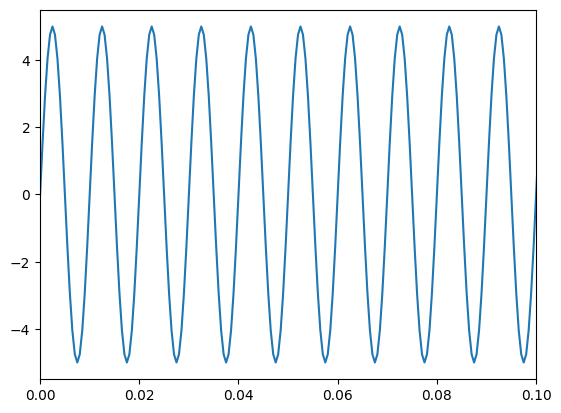

In [ ]:
plt.plot(t,x)
plt.xlim(0,0.1)

(0.0, 100.0)

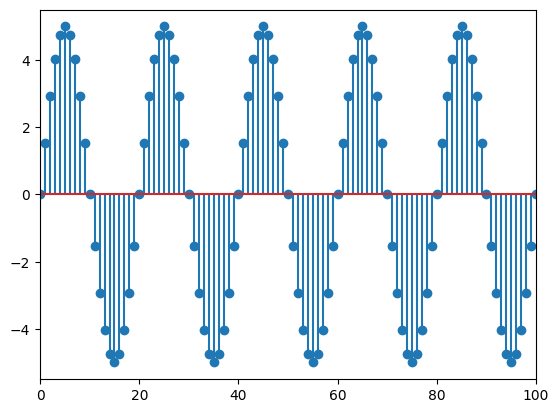

In [ ]:
plt.stem(n,x)
plt.xlim(0,100)

Representación espectral

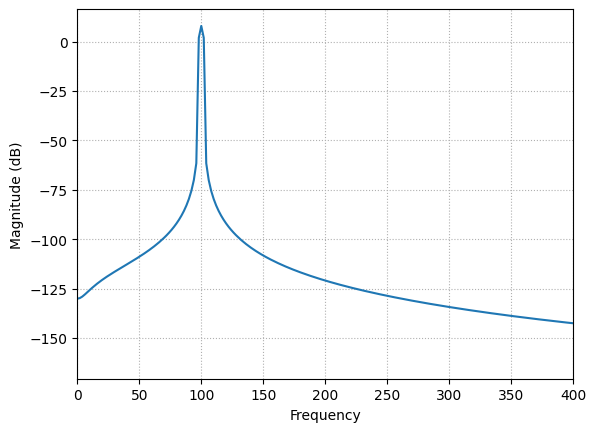

In [ ]:
plt.magnitude_spectrum(x, Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0,400)
plt.show()

Frecuencia vs tiempo, STFT


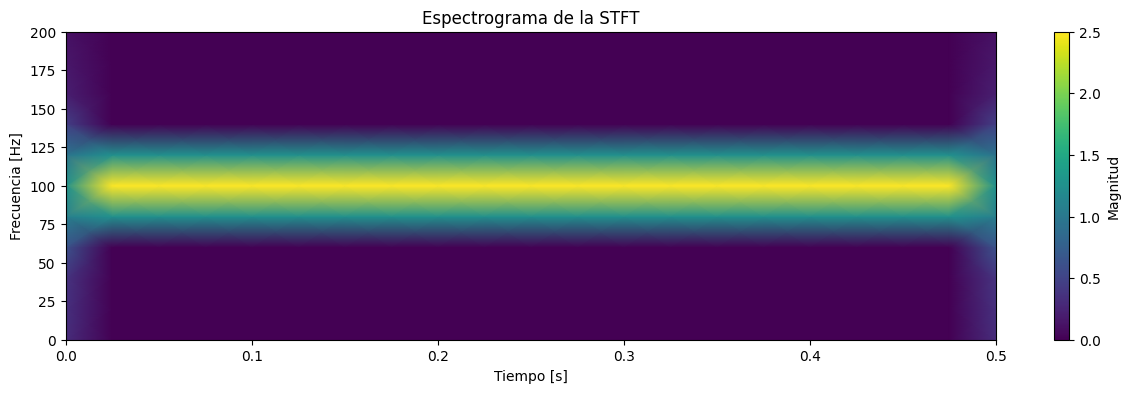

In [ ]:
f, t, Zxx = signal.stft(x, fs, nperseg=100)

# Graficar el espectrograma
plt.figure(figsize=(15, 4))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('Espectrograma de la STFT')
plt.ylabel('Frecuencia [Hz]')
plt.xlabel('Tiempo [s]')
plt.ylim(0,200)
plt.colorbar(label='Magnitud')
plt.show()

✅ Señal 1 f = 10 Hz

In [ ]:
A =10
phi = np.pi/4
f = 100
w = 2*np.pi*f
fs  = 50 * f
Ts  =1/fs
n = np.arange(1000)
t = n*Ts
x = A*np.sin(w*t + phi)

(0.0, 0.1)

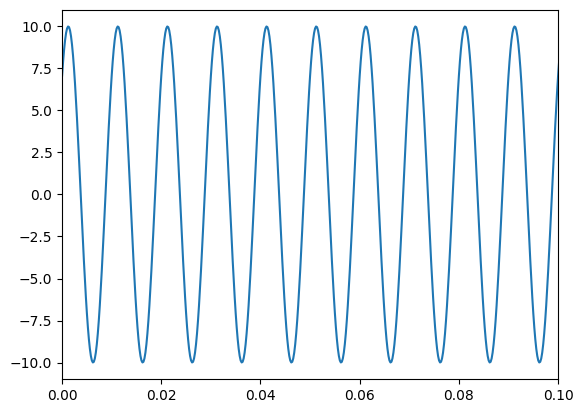

In [ ]:
plt.plot(t,x)
plt.xlim(0,0.1)

(0.0, 100.0)

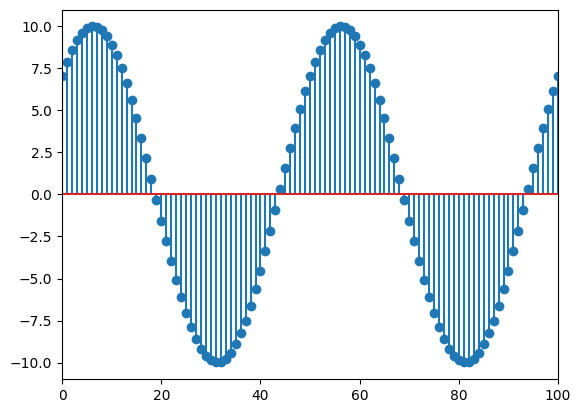

In [ ]:
plt.stem(n,x)
plt.xlim(0,100)

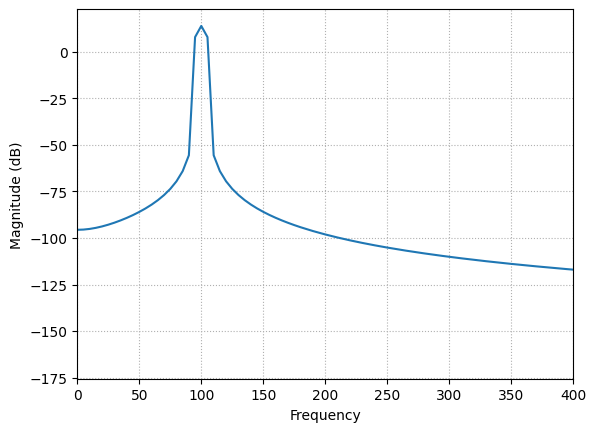

In [ ]:
plt.magnitude_spectrum(x, Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0,400)
plt.show()

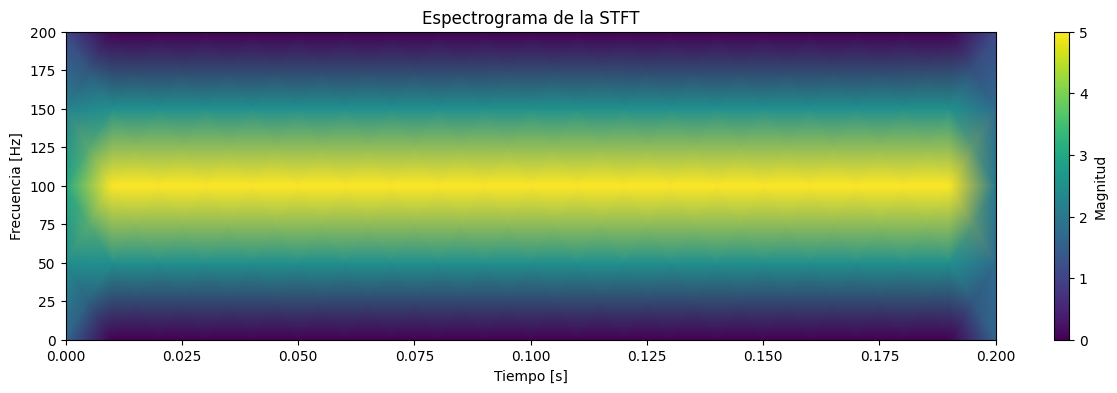

In [ ]:
f, t, Zxx = signal.stft(x, fs, nperseg=100)

# Graficar el espectrograma
plt.figure(figsize=(15, 4))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('Espectrograma de la STFT')
plt.ylabel('Frecuencia [Hz]')
plt.xlabel('Tiempo [s]')
plt.ylim(0,200)
plt.colorbar(label='Magnitud')
plt.show()

✅ Señal 1 f = 50 Hz

In [ ]:
A =10
phi = np.pi/6
duracion = 0.1
f = 50
w = 2*np.pi*f
fs  = 20* f
Ts  =1/fs
n = np.arange(int(duracion * fs))
t = n*Ts
x = A*np.cos(w*t + phi)

(0.0, 100.0)

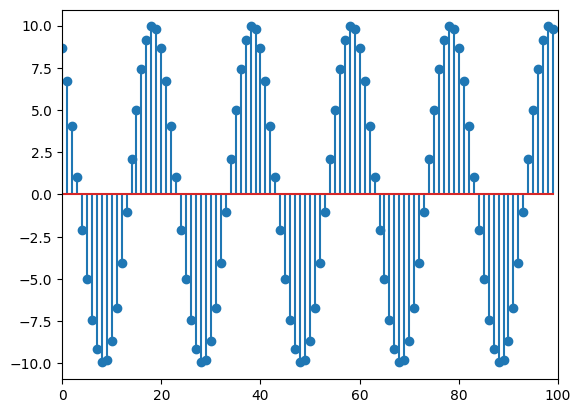

In [ ]:
plt.stem(n,x)
plt.xlim(0,100)

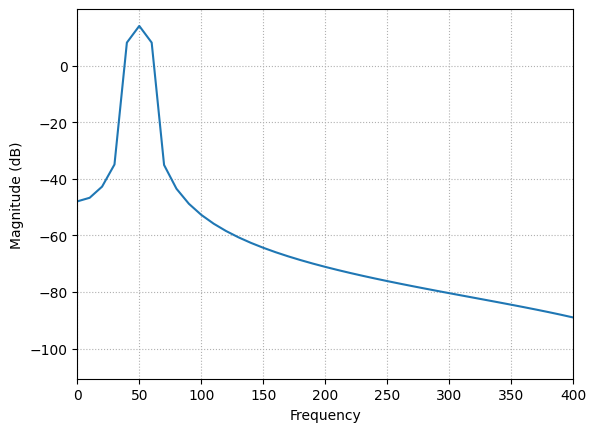

In [ ]:
plt.magnitude_spectrum(x, Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0,400)
plt.show()

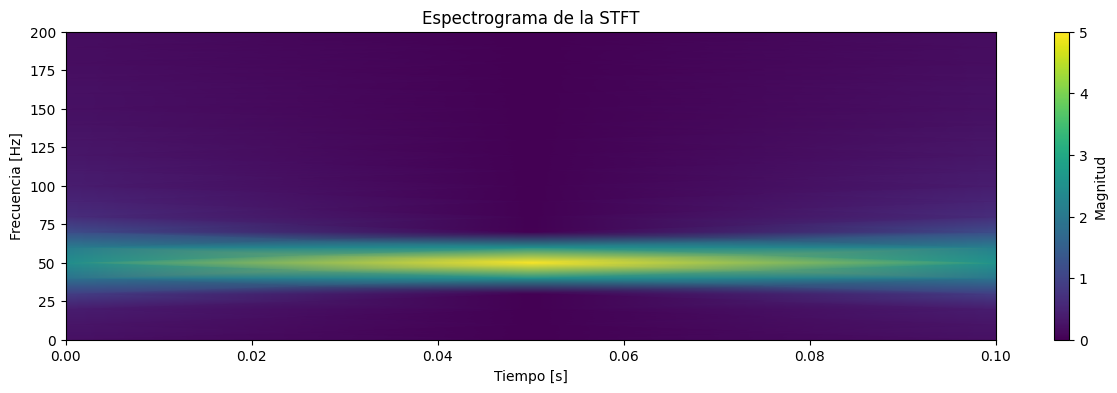

In [ ]:
f, t, Zxx = signal.stft(x, fs, nperseg=100)

# Graficar el espectrograma
plt.figure(figsize=(15, 4))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('Espectrograma de la STFT')
plt.ylabel('Frecuencia [Hz]')
plt.xlabel('Tiempo [s]')
plt.ylim(0,200)
plt.colorbar(label='Magnitud')
plt.show()

3. Cargar señales de PhysioNet

In [27]:
#!pip install wfdb
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.fft import fft, fftfreq

Señal 1

In [31]:
record = wfdb.rdrecord('100', pn_dir='mitdb')

ecg = record.p_signal[:,0]
fs_ecg = record.fs

t = np.arange(len(ecg))/fs_ecg

N_5s = int(5 * fs_ecg)
ecg = ecg[:N_5s]
t = t[:N_5s]

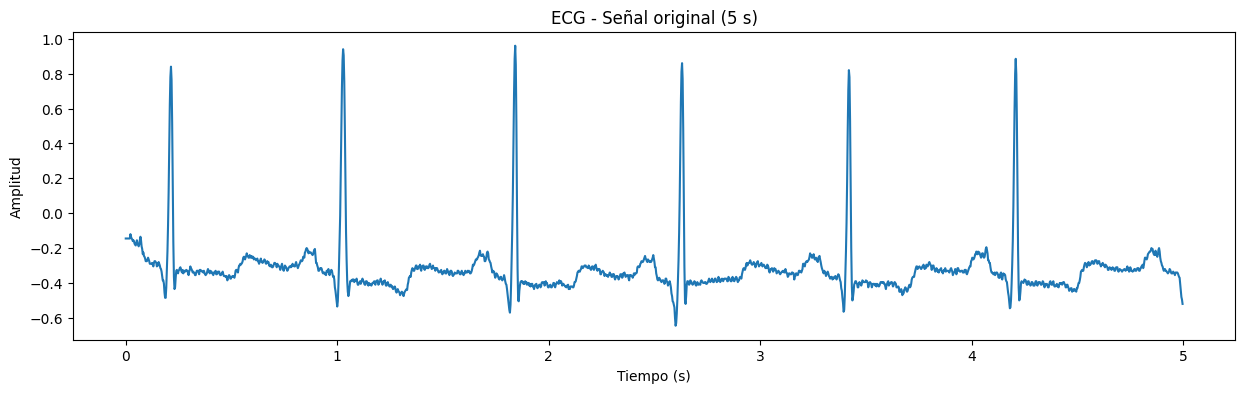

In [32]:
plt.figure(figsize=(15,4))
plt.plot(t, ecg)
plt.title('ECG - Señal original (5 s)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

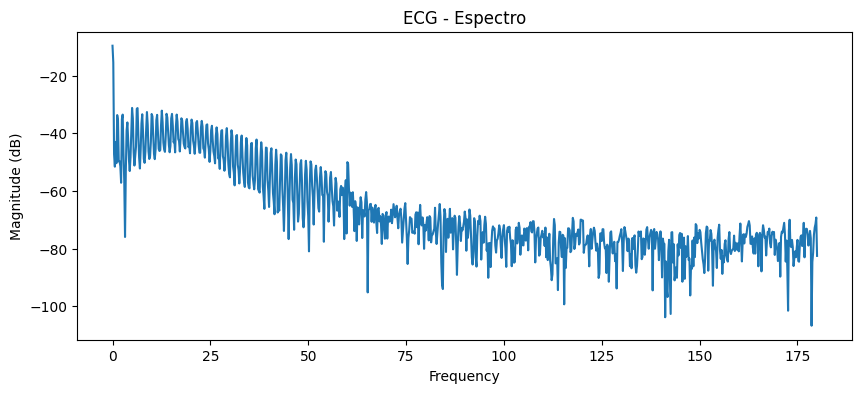

In [60]:
plt.figure(figsize=(10,4))
plt.magnitude_spectrum(ecg, Fs=fs_ecg, scale='dB')
plt.title('ECG - Espectro')
plt.show()

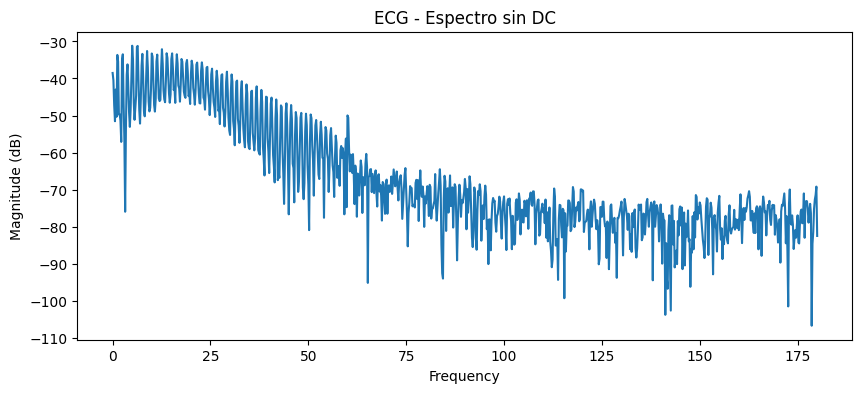

In [59]:
ecg_dc = ecg - np.mean(ecg)

plt.figure(figsize=(10,4))
plt.magnitude_spectrum(ecg_dc, Fs=fs_ecg, scale='dB')
plt.title('ECG - Espectro sin DC')
plt.show()

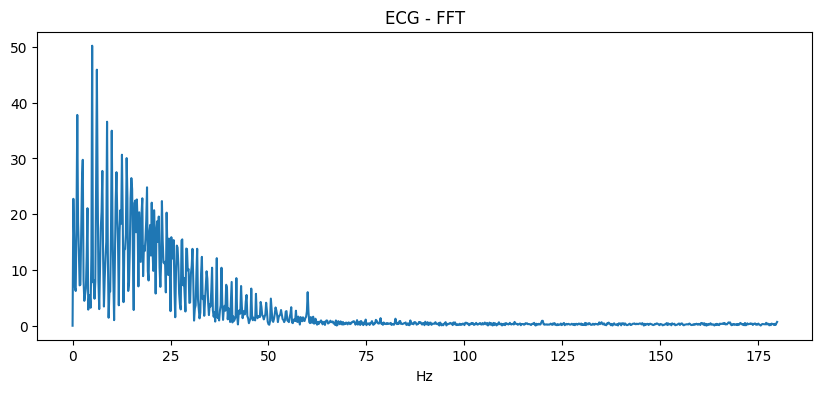

In [38]:
N = len(ecg_dc)
X = fft(ecg_dc)
freqs = fftfreq(N, 1/fs_ecg)

idx = freqs >= 0

plt.figure(figsize=(10,4))
plt.plot(freqs[idx], np.abs(X[idx]))
plt.title('ECG - FFT')
plt.xlabel('Hz')
plt.show()

In [40]:
# Bandpass 0.5–40 Hz
b, a = signal.butter(4, [0.5/(fs_ecg/2), 40/(fs_ecg/2)], btype='band')
ecg_filt = signal.filtfilt(b, a, ecg_dc)

# Notch 60 Hz
b_notch, a_notch = signal.iirnotch(60, 30, fs_ecg)
ecg_filt = signal.filtfilt(b_notch, a_notch, ecg_filt)

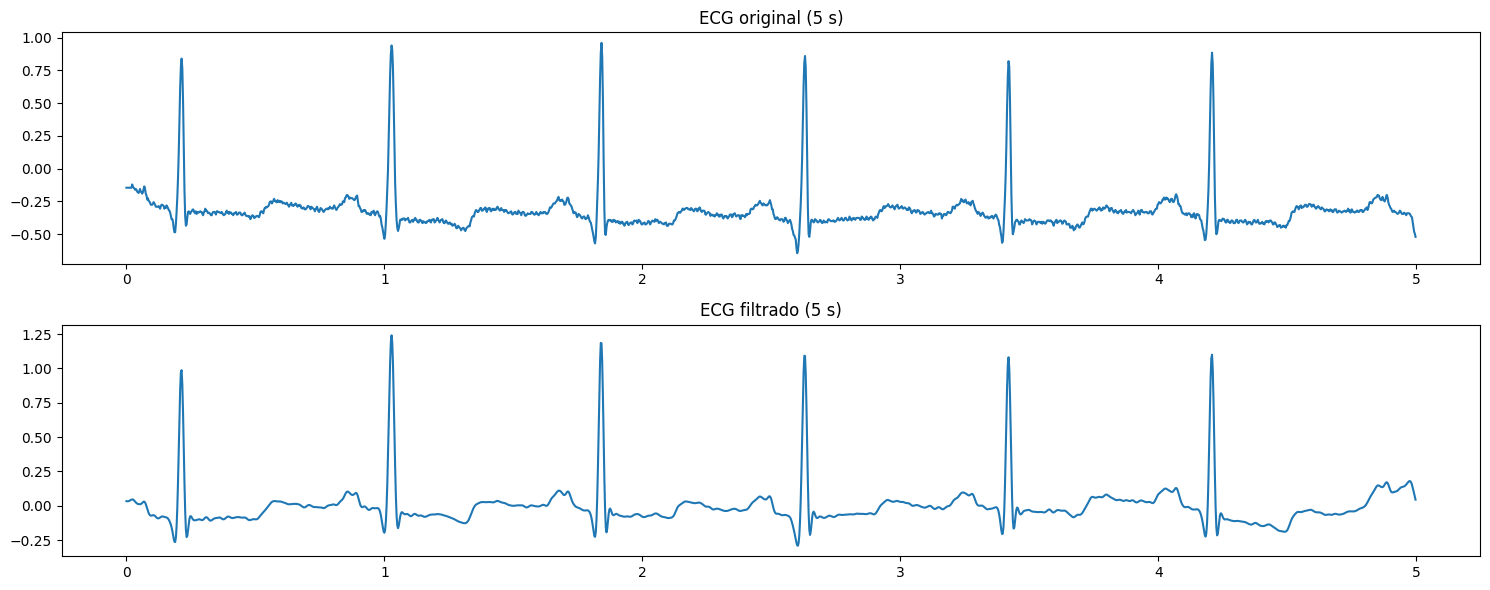

In [41]:
plt.figure(figsize=(15,6))

plt.subplot(2,1,1)
plt.plot(t, ecg)
plt.title('ECG original (5 s)')

plt.subplot(2,1,2)
plt.plot(t, ecg_filt)
plt.title('ECG filtrado (5 s)')

plt.tight_layout()
plt.show()

Señal 2

In [43]:
record = wfdb.rdrecord('emg_healthy', pn_dir='emgdb')

emg = record.p_signal[:,0]
fs_emg = record.fs

t = np.arange(len(emg))/fs_emg

N_5s = int(5 * fs_emg)
emg = emg[:N_5s]
t = t[:N_5s]

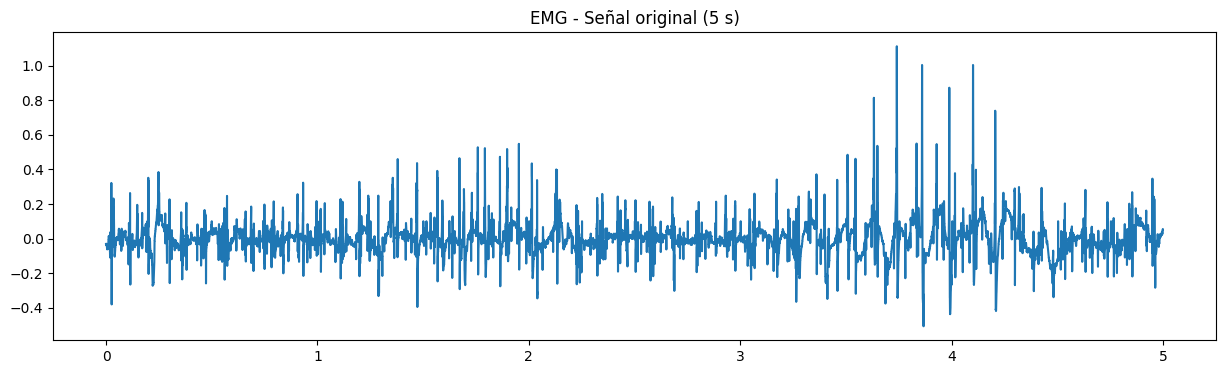

In [44]:
plt.figure(figsize=(15,4))
plt.plot(t, emg)
plt.title('EMG - Señal original (5 s)')
plt.show()

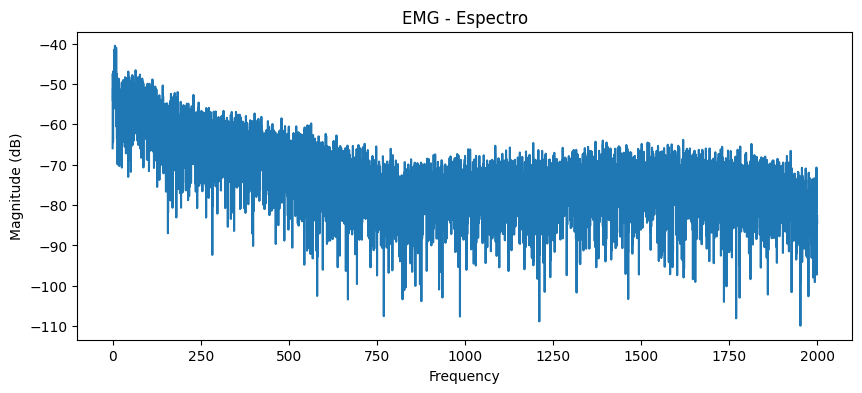

In [57]:
plt.figure(figsize=(10,4))
plt.magnitude_spectrum(emg, Fs=fs_emg, scale='dB')
plt.title('EMG - Espectro')
plt.show()

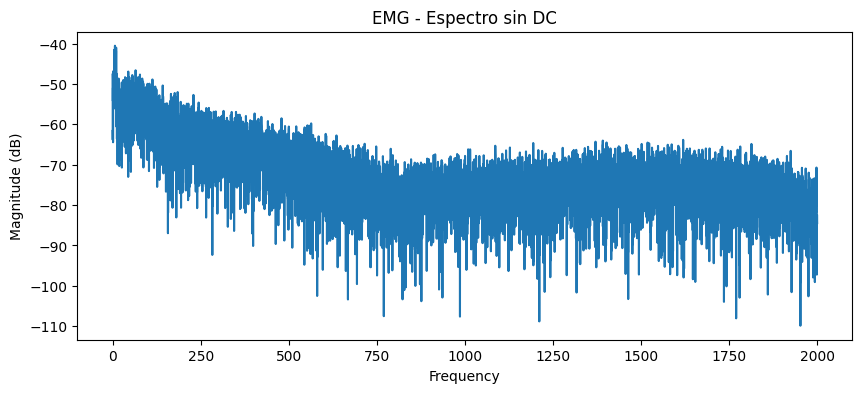

In [58]:
emg_dc = emg - np.mean(emg)

plt.figure(figsize=(10,4))
plt.magnitude_spectrum(emg_dc, Fs=fs_emg, scale='dB')
plt.title('EMG - Espectro sin DC')
plt.show()

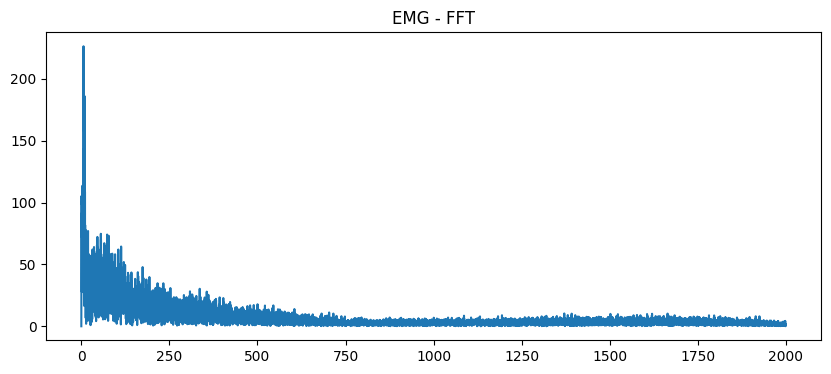

In [47]:
N = len(emg_dc)
X = fft(emg_dc)
freqs = fftfreq(N, 1/fs_emg)

idx = freqs >= 0

plt.figure(figsize=(10,4))
plt.plot(freqs[idx], np.abs(X[idx]))
plt.title('EMG - FFT')
plt.show()

In [48]:
# Bandpass 20–450 Hz
b, a = signal.butter(4, [20/(fs_emg/2), 450/(fs_emg/2)], btype='band')
emg_filt = signal.filtfilt(b, a, emg_dc)

# Notch
b_notch, a_notch = signal.iirnotch(60, 30, fs_emg)
emg_filt = signal.filtfilt(b_notch, a_notch, emg_filt)

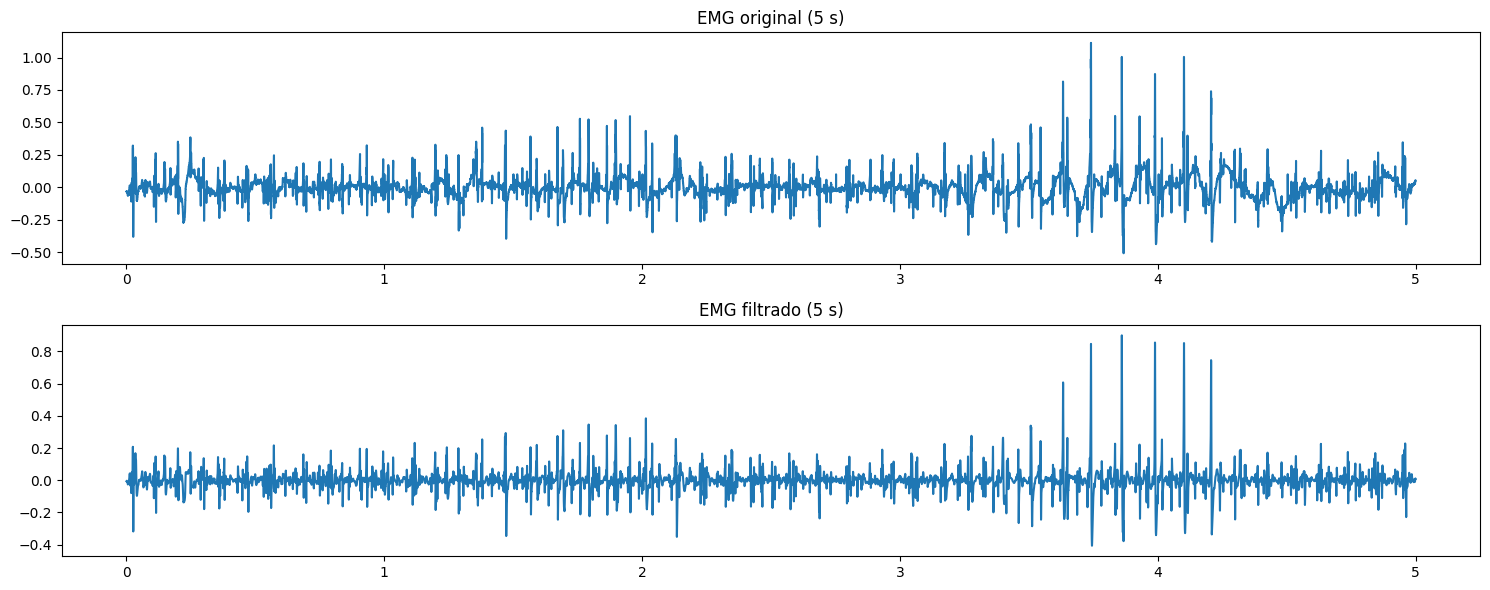

In [49]:
plt.figure(figsize=(15,6))

plt.subplot(2,1,1)
plt.plot(t, emg)
plt.title('EMG original (5 s)')

plt.subplot(2,1,2)
plt.plot(t, emg_filt)
plt.title('EMG filtrado (5 s)')

plt.tight_layout()
plt.show()